# 02 - Physics-Grounded Generation Engines
### poropack: 3D Porous Media & Digital Rock Physics Generator

This notebook demonstrates the three physical and continuum porous media generators:
1. **Ballistic Sedimentation ("Drop-and-Roll")**: Gravitational settling with 4-stage analytical kinematics and mechanical contact network tracking.
2. **Dense Random Packing (FBA + FIRE)**: Collective rearrangement breaking the RSA jamming limit ($\phi \ge 0.60$, porosity $\le 0.40$).
3. **Continuum Bicontinuous Media**: 3D Spectral Gaussian Random Fields (GRF) and Quartet Structure Generation Set (QSGS).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import poropack as pp

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11


## 1. Ballistic Sedimentation ("Drop-and-Roll") under Gravity

Natural sedimentary rocks originate from gravitational deposition into a basin:
1. **Free Fall**: Grains drop vertically from the top of the box.
2. **1-Point Contact**: Rolling along the steepest gradient on a struck sphere.
3. **2-Point Contact**: Rolling along the contact valley formed between two resting spheres.
4. **3-Point Stable Equilibrium**: Mechanical resting position, or substrate floor contact at $z=0$.


Sedimentation Pack Summary:
  Grains Deposited: 350
  Contact Tracking: 350 grains recorded


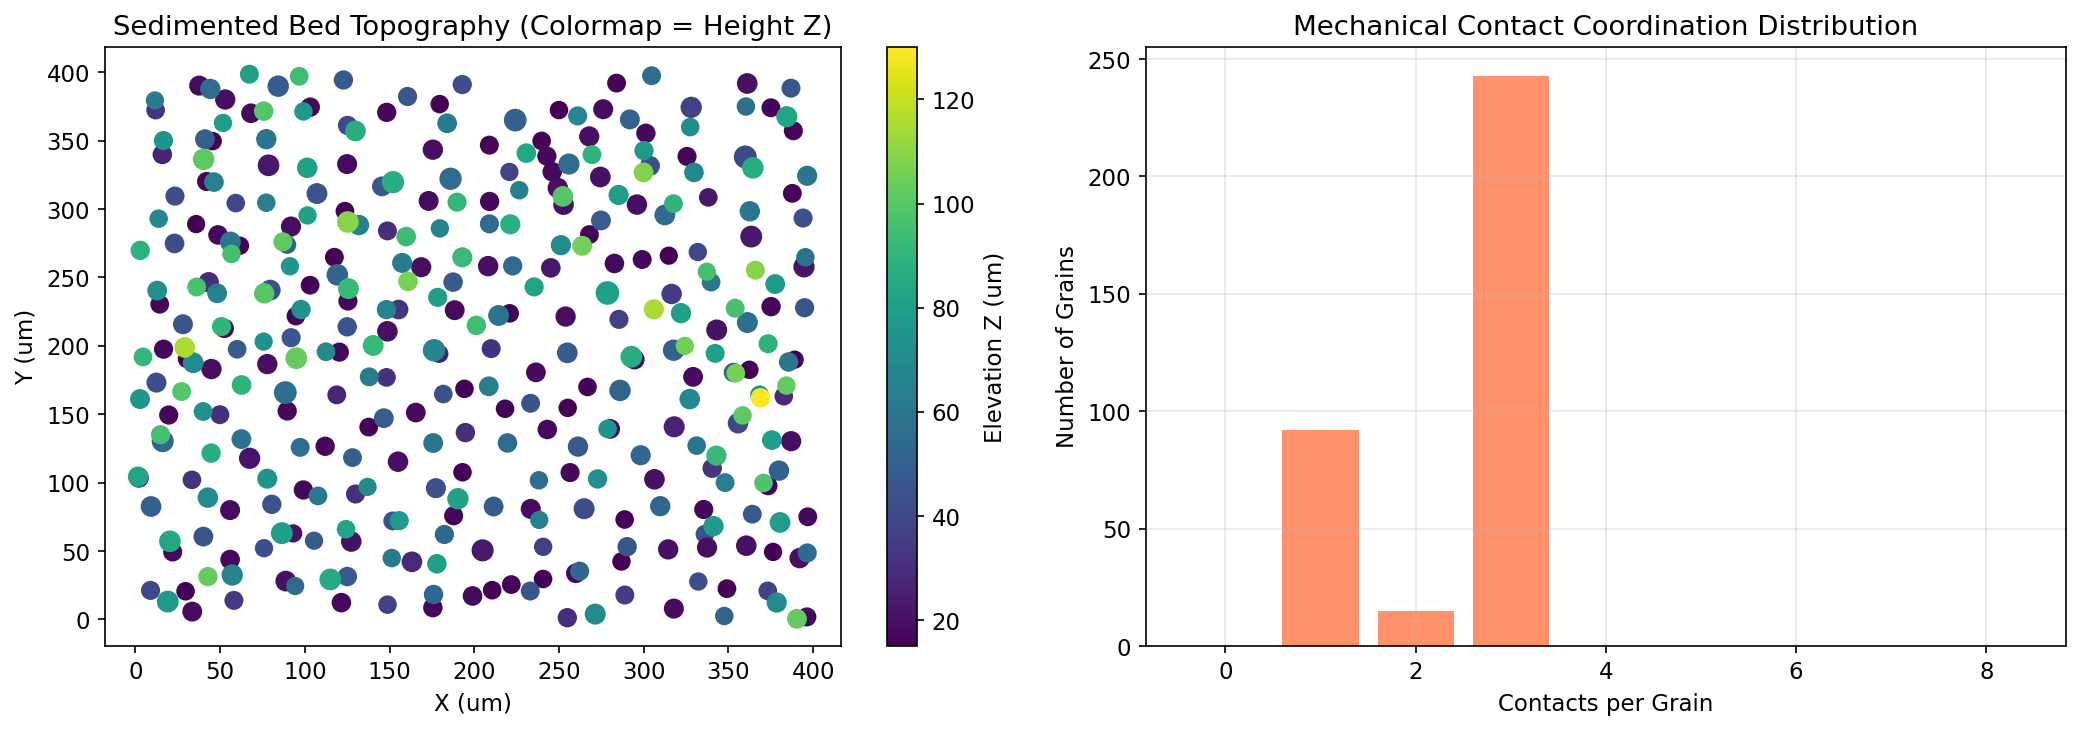

In [2]:
sed_gen = pp.SedimentationGenerator(
    box_size=(400.0, 400.0, 500.0),
    psd=pp.LogNormalPSD(d50=35.0, sigma_phi=0.25, bounds=(15.0, 60.0)),
    periodic_xy=True,
    random_state=42,
)

pack_sed = sed_gen.generate(n_spheres=350)
print('Sedimentation Pack Summary:')
print(f'  Grains Deposited: {len(pack_sed)}')
print(f'  Contact Tracking: {len(pack_sed.attributes.get("contacts", []))} grains recorded')

# Plot depositional bed topography and coordination number histogram
contacts = pack_sed.attributes['contacts']
coordination_numbers = [len(c) for c in contacts]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(pack_sed.coords[:, 0], pack_sed.coords[:, 1], c=pack_sed.coords[:, 2], s=pack_sed.radii*4, cmap='viridis')
axes[0].set_title('Sedimented Bed Topography (Colormap = Height Z)')
axes[0].set_xlabel('X (um)')
axes[0].set_ylabel('Y (um)')
plt.colorbar(sc, ax=axes[0], label='Elevation Z (um)')

axes[1].hist(coordination_numbers, bins=range(0, 10), align='left', rwidth=0.8, color='coral', alpha=0.85)
axes[1].set_title('Mechanical Contact Coordination Distribution')
axes[1].set_xlabel('Contacts per Grain')
axes[1].set_ylabel('Number of Grains')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Dense Random Close Packing via Force-Biased Algorithm (FBA + FIRE)

Random Sequential Adsorption (RSA) jams irreversibly at low packing fractions ($\phi pprox 0.35 - 0.38$).

`poropack.DensePackingGenerator` employs:
- Soft Hookean repulsive contact potentials $F_{ij} = k \delta_{ij} \hat{n}_{ij}$.
- Fast Inertial Relaxation Engine (FIRE) energy minimization.
- Staged radius inflation followed by uniform radius deflation $r_i \leftarrow r_i - \delta_{\max}/2$ to guarantee **strict zero overlap** while reaching dense close-packed densities ($\phi \ge 0.60$).


In [3]:
dense_gen = pp.DensePackingGenerator(
    box_size=(160.0, 160.0, 160.0),
    psd=pp.LogNormalPSD(d50=25.0, sigma_phi=0.20, bounds=(10.0, 35.0)),
    random_state=42,
)

pack_dense = dense_gen.generate(n_spheres=250, target_solid_fraction=0.60)
phi_solid = 1.0 - pack_dense.analytical_porosity()

print('Dense Packing Result:')
print(f'  Spheres:                     {len(pack_dense)}')
print(f'  Solid Volume Fraction (phi): {phi_solid:.4f}')
print(f'  Porosity:                    {pack_dense.analytical_porosity():.4f}')
print('  RSA Jamming Limit (~0.35) successfully broken with ZERO particle overlap!')


Dense Packing Result:
  Spheres:                     250
  Solid Volume Fraction (phi): 0.5999
  Porosity:                    0.4001
  RSA Jamming Limit (~0.35) successfully broken with ZERO particle overlap!


## 3. Continuum Bicontinuous Media (Spectral GRF & QSGS)

For micro-porous digital rocks, carbonates, and vuggy media where grain boundaries are irregular:
- **Spectral Gaussian Random Fields (GRF)**: Filters 3D Gaussian noise in Fourier space with Gaussian, Exponential, or Von Kármán covariance kernels and applies exact inverse-CDF thresholding to hit the requested porosity precisely.
- **Quartet Structure Generation Set (QSGS)**: Mimics stochastic seed nucleation and anisotropic crystal cluster expansion.


GRF Target: 0.3200 -> Actual Porosity:  0.3195
QSGS Target: 0.3200 -> Actual Porosity: 0.2993


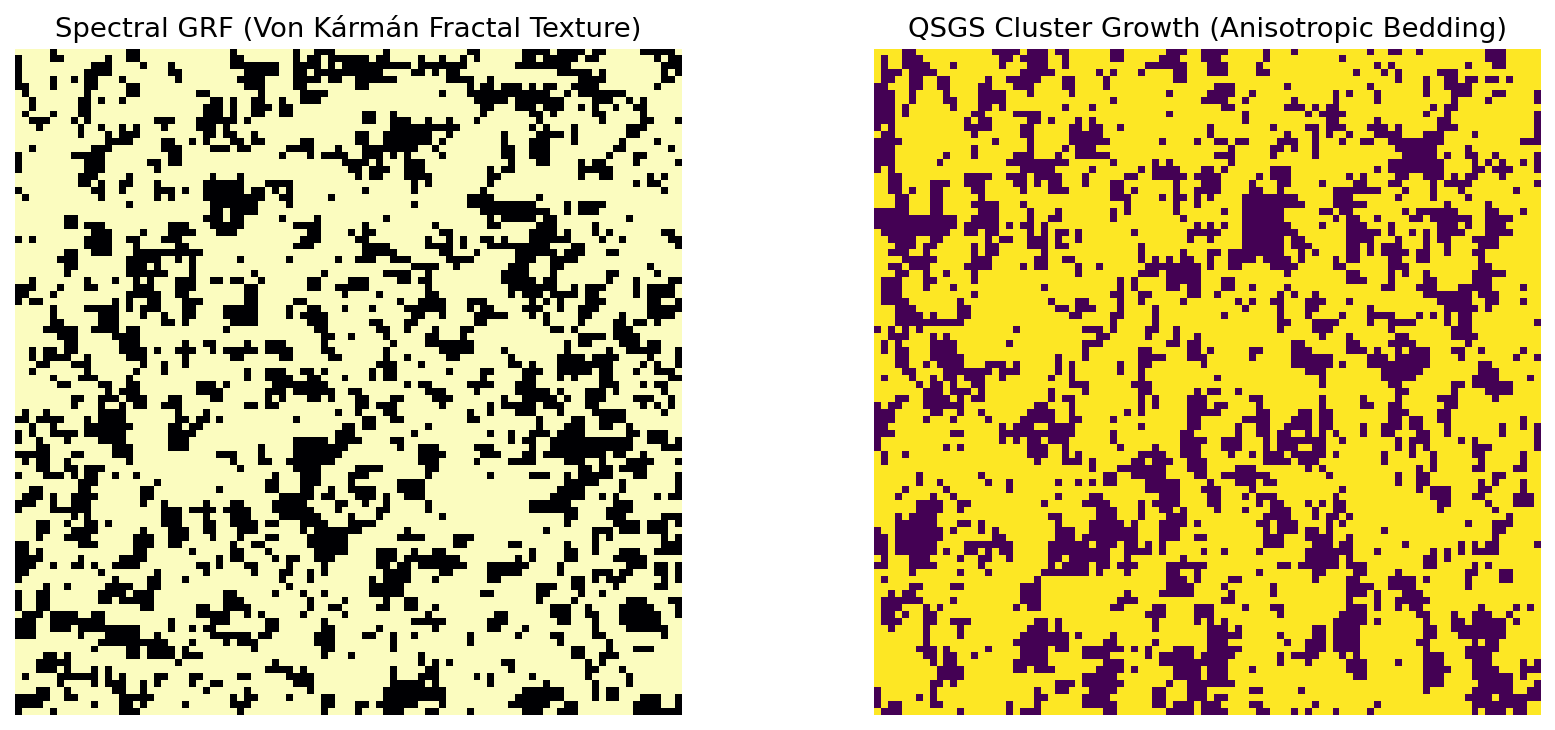

In [4]:
# 1. Spectral GRF with Von Karman kernel (self-affine roughness)
grf = pp.GaussianRandomField(
    shape=(96, 96, 96),
    voxel_size=2.0,
    correlation_length=14.0,
    kernel='von_karman',
    random_state=42,
)
grid_grf = grf.generate(target_porosity=0.32)

# 2. QSGS Stochastic Cluster Matrix
qsgs = pp.QSGSGenerator(
    shape=(96, 96, 96),
    voxel_size=2.0,
    core_probability=0.015,
    growth_probabilities=(0.12, 0.12, 0.06), # Px=Py > Pz induces horizontal bedding
    random_state=42,
)
grid_qsgs = qsgs.generate(target_porosity=0.32)

print(f'GRF Target: 0.3200 -> Actual Porosity:  {grid_grf.porosity():.4f}')
print(f'QSGS Target: 0.3200 -> Actual Porosity: {grid_qsgs.porosity():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(grid_grf.matrix[48, :, :], cmap='magma')
axes[0].set_title('Spectral GRF (Von Kármán Fractal Texture)')
axes[0].axis('off')

axes[1].imshow(grid_qsgs.matrix[48, :, :], cmap='viridis')
axes[1].set_title('QSGS Cluster Growth (Anisotropic Bedding)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
